# Business Decision Simulations — Price Monte Carlo

This notebook turns the EDA + clustering work into decision-support tools using **Monte Carlo simulation**, built entirely from your own historical data (no external assumptions or new libraries needed).

**Core idea:** decompose a commodity's price into trend + seasonal + residual (already done via STL in the earlier notebooks), extrapolate trend and seasonal forward, then **block-bootstrap the historical residuals** thousands of times to generate a distribution of plausible future price paths — not just one point forecast.

Sections (built incrementally):
1. Monte Carlo simulation engine (reusable for everything below)
2. **Farmer selling-window simulation** — best month to sell, balancing expected price against downside risk
3. *(next)* Retailer procurement budget risk (VaR/CVaR)
4. *(next)* Portfolio diversification across clusters
5. *(next)* Consumer buy-timing indicator

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
%matplotlib inline
np.random.seed(42)  # reproducibility -- remove or change to get different simulation draws


# ---- Project root: resolved relative to this notebook, independent of the machine/OS it runs on ----
def _find_project_root(marker=os.path.join("data", "raw", "kalimati_tarkari_dataset.csv")):
    path = os.getcwd()
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            break
        path = parent
    raise FileNotFoundError(
        "Could not locate the project root (expected to find data/raw/kalimati_tarkari_dataset.csv "
        "within a few parent directories of the current working directory).")


PROJECT_ROOT = _find_project_root()

# ---- CONFIG ----
CSV_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "kalimati_tarkari_dataset.csv")
DATE_COL = "Date"
COMMODITY_COL = "Commodity"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "reports", "from notebooks", "simulation_outputs")

N_SIMS = 1000          # number of simulated future price paths
HORIZON_DAYS = 365     # how far ahead to simulate
BLOCK_SIZE = 14        # bootstrap block length (days) -- preserves short-term autocorrelation in noise
TREND_LOOKBACK_DAYS = 180   # how much recent trend history to use when extrapolating the trend slope

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
for col in ["Minimum", "Maximum", "Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=[DATE_COL, COMMODITY_COL, "Average"])
df = (df.groupby([COMMODITY_COL, DATE_COL], as_index=False)
        .agg({"Unit": "first", "Minimum": "mean", "Maximum": "mean", "Average": "mean"}))
df = df.sort_values([COMMODITY_COL, DATE_COL]).reset_index(drop=True)

print(f"{len(df)} rows, {df[COMMODITY_COL].nunique()} commodities, "
      f"{df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")

197161 rows, 132 commodities, 2013-06-16 to 2021-05-13


## 1. Monte Carlo Simulation Engine

This is the reusable core. Given a commodity, it:

1. Fits STL to the historical daily series (same as the EDA/clustering notebooks).
2. **Extrapolates the trend** forward using a simple linear fit on the most recent `TREND_LOOKBACK_DAYS` of the trend component — captures recent drift without assuming it continues forever at a wild rate.
3. **Extrapolates the seasonal component** by looking up the historical average seasonal effect for each future date's day-of-year — since seasonality is (by definition) a repeating annual pattern, we don't need to forecast it, just replay it.
4. **Block-bootstraps the residuals**: instead of resampling single random days (which would erase realistic short-term momentum, e.g. a price spike that persists for a week), it resamples contiguous `BLOCK_SIZE`-day chunks of historical residuals and stitches them together to fill the horizon. Each of the `N_SIMS` simulations gets an independently resampled noise sequence.
5. Adds the three components back together → one simulated price path per simulation.

In [3]:
def fit_stl(df, commodity, period=365):
    g = (df[df[COMMODITY_COL] == commodity]
         .set_index(DATE_COL)["Average"].sort_index().asfreq("D"))
    g = g.interpolate(limit=14).dropna()
    if len(g) < period * 1.5:
        raise ValueError(f"{commodity}: not enough history for a yearly STL fit "
                          f"({len(g)} days, need ~{int(period*1.5)})")
    res = STL(g, period=period, robust=True).fit()
    return g, res


def extrapolate_trend(trend, horizon_days, lookback_days=TREND_LOOKBACK_DAYS):
    recent = trend.iloc[-lookback_days:]
    x = np.arange(len(recent))
    slope, intercept = np.polyfit(x, recent.values, 1)
    last_value = trend.iloc[-1]
    future_x = np.arange(1, horizon_days + 1)
    # anchor at the last observed trend value, extend using the fitted recent slope
    return last_value + slope * future_x


def extrapolate_seasonal(seasonal, future_dates):
    # average historical seasonal effect by day-of-year, then look it up for each future date
    doy_avg = seasonal.groupby(seasonal.index.dayofyear).mean()
    future_doy = future_dates.dayofyear
    # day 366 (leap years) falls back to day 365's value if not present historically
    return np.array([doy_avg.get(d, doy_avg.get(365)) for d in future_doy])


def block_bootstrap_residuals(resid, horizon_days, block_size=BLOCK_SIZE, n_sims=N_SIMS):
    resid_vals = resid.values
    n = len(resid_vals)
    n_blocks_needed = int(np.ceil(horizon_days / block_size))
    sims = np.zeros((n_sims, horizon_days))
    for s in range(n_sims):
        blocks = []
        for _ in range(n_blocks_needed):
            start = np.random.randint(0, n - block_size)
            blocks.append(resid_vals[start:start + block_size])
        sims[s] = np.concatenate(blocks)[:horizon_days]
    return sims


def simulate_price_paths(df, commodity, horizon_days=HORIZON_DAYS, n_sims=N_SIMS, block_size=BLOCK_SIZE):
    g, res = fit_stl(df, commodity)
    last_date = g.index[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon_days, freq="D")

    trend_future = extrapolate_trend(res.trend, horizon_days)
    seasonal_future = extrapolate_seasonal(res.seasonal, future_dates)
    resid_sims = block_bootstrap_residuals(res.resid, horizon_days, block_size, n_sims)

    price_paths = trend_future[None, :] + seasonal_future[None, :] + resid_sims
    price_paths = np.clip(price_paths, a_min=0, a_max=None)  # prices can't go negative

    return pd.DataFrame(price_paths, columns=future_dates), g, res

**Notes on the assumptions here** (worth stating explicitly for a business audience):
- The trend extrapolation assumes the *recent* slope continues — it will not anticipate genuine structural breaks (new policy, major supply shock) that haven't shown up in the last `TREND_LOOKBACK_DAYS`.
- The seasonal pattern is assumed to repeat as it has historically — reasonable for weather/harvest-driven seasonality, less reliable if the growing calendar itself is shifting (climate change, new cultivation techniques).
- Block bootstrap preserves the *magnitude and short-term persistence* of historical noise but doesn't know about future one-off shocks (a new drought, an import ban) that have no historical precedent in the residuals.
- These are appropriate caveats to include in any report generated from this — the simulation shows a realistic *range* of "more of the same," not a crystal ball for unprecedented events.

## 2. Sanity Check — Visualize One Simulation

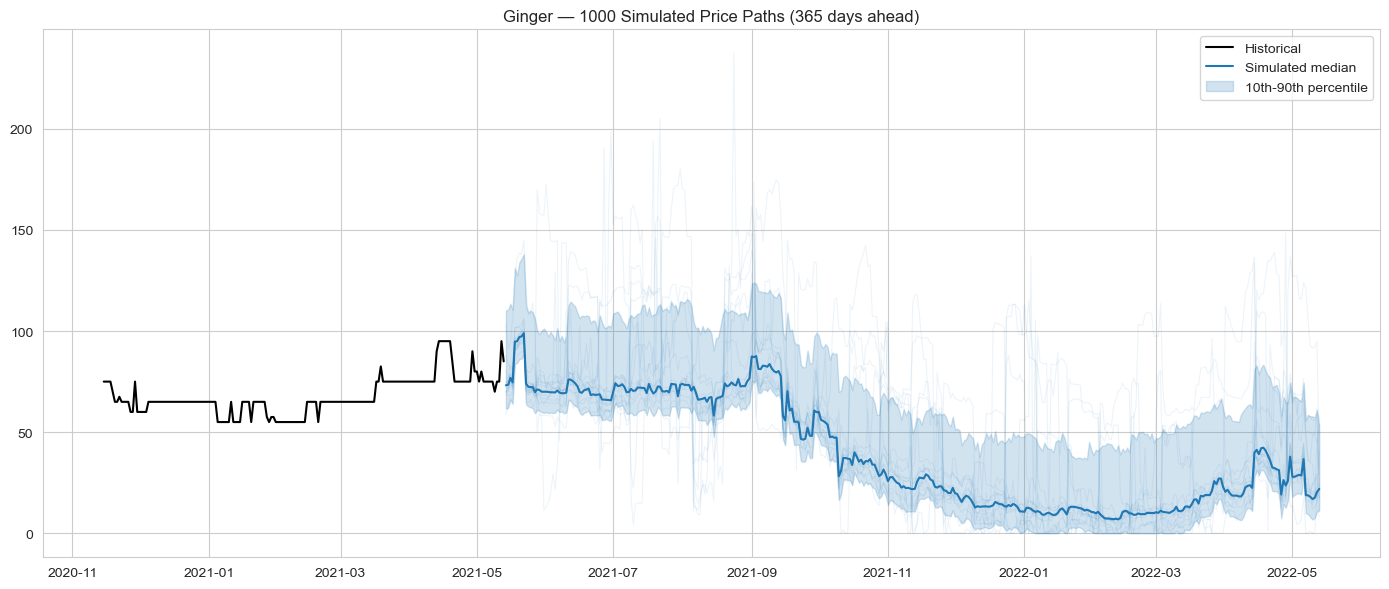

In [4]:
DEMO_COMMODITY = df[COMMODITY_COL].value_counts().index[0]   # highest-volume commodity as a demo; change as needed

paths, g_hist, stl_res = simulate_price_paths(df, DEMO_COMMODITY)

fig, ax = plt.subplots(figsize=(14, 6))
# recent history for context
recent_hist = g_hist.iloc[-180:]
ax.plot(recent_hist.index, recent_hist.values, color="black", label="Historical")

# simulated fan chart
future_dates = paths.columns
median_path = paths.median(axis=0)
p10 = paths.quantile(0.10, axis=0)
p90 = paths.quantile(0.90, axis=0)

ax.plot(future_dates, median_path, color="tab:blue", label="Simulated median")
ax.fill_between(future_dates, p10, p90, alpha=0.2, color="tab:blue", label="10th-90th percentile")
for s in np.random.choice(paths.index, size=15, replace=False):
    ax.plot(future_dates, paths.loc[s], color="tab:blue", alpha=0.08, linewidth=0.8)

ax.set_title(f"{DEMO_COMMODITY} — {N_SIMS} Simulated Price Paths ({HORIZON_DAYS} days ahead)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/demo_simulation_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

## 3. Farmer Selling-Window Simulation

**Business question:** *"Which month should I plan to bring this commodity to market to get the best price, without betting on a month that's high on average but wildly unreliable?"*

For each simulated path, group the simulated daily prices by future calendar month. Across all simulations, this gives a full distribution of "what price might I get in month X" — not just an average, but how much that average could vary.

**Ranking logic:** the best month isn't just the one with the highest expected price — a month with a slightly lower average but much tighter spread may be the safer bet for a farmer who can't afford a bad-case outcome. We rank using a simple **risk-adjusted score**: `expected_price - RISK_AVERSION * std_price`. Increase `RISK_AVERSION` if you want the recommendation to favor safety over upside.

In [5]:
RISK_AVERSION = 0.5   # 0 = purely maximize expected price; higher = more weight on avoiding downside variance

def farmer_selling_window(paths, risk_aversion=RISK_AVERSION):
    future_dates = paths.columns
    month_labels = future_dates.month

    records = []
    for m in sorted(set(month_labels)):
        cols = future_dates[month_labels == m]
        month_prices = paths[cols].values.flatten()  # all sims x all days in that month, pooled
        records.append({
            "month": m,
            "expected_price": month_prices.mean(),
            "std_price": month_prices.std(),
            "p10": np.percentile(month_prices, 10),
            "p90": np.percentile(month_prices, 90),
            "cv": month_prices.std() / month_prices.mean(),
        })
    result = pd.DataFrame(records)
    result["risk_adjusted_score"] = result["expected_price"] - risk_aversion * result["std_price"]
    result = result.sort_values("risk_adjusted_score", ascending=False).reset_index(drop=True)
    result["rank"] = result.index + 1
    return result

selling_window = farmer_selling_window(paths)
selling_window

,month,expected_price,std_price,p10,p90,cv,risk_adjusted_score,rank
0,7,76.428425,22.760724,60.266681,109.813277,0.297804,65.048063,1
1,8,74.782275,22.745757,57.996715,106.021070,0.304160,63.409397,2
2,6,74.180881,21.836357,58.877500,104.810508,0.294366,63.262703,3
3,9,72.481906,26.825646,45.051335,101.386131,0.370101,59.069083,4
4,5,60.879046,35.418980,16.894214,100.643609,0.581793,43.169556,5
5,10,43.997644,23.662093,23.781563,75.900201,0.537804,32.166597,6
6,4,33.690460,24.202918,12.172146,66.505073,0.718391,21.589001,7
7,11,29.032271,21.095652,12.915841,59.147702,0.726628,18.484445,8
8,3,21.691576,21.986583,2.600096,54.267378,1.013600,10.698284,9
9,12,19.623996,20.140989,3.344216,47.026158,1.026345,9.553501,10


In [6]:
best_month = selling_window.iloc[0]
print(f"Recommended selling month for {DEMO_COMMODITY}: month {int(best_month['month'])}")
print(f"  Expected price: {best_month['expected_price']:.2f}")
print(f"  Typical range (P10-P90): {best_month['p10']:.2f} - {best_month['p90']:.2f}")
print(f"  Volatility (CV): {best_month['cv']:.2f}")

# also show the "highest average price" month for comparison -- may differ from the risk-adjusted pick
highest_avg_month = selling_window.sort_values('expected_price', ascending=False).iloc[0]
if highest_avg_month['month'] != best_month['month']:
    print(f"\nNote: month {int(highest_avg_month['month'])} has the highest raw average price "
          f"({highest_avg_month['expected_price']:.2f}) but scores lower once volatility is factored in "
          f"(CV={highest_avg_month['cv']:.2f} vs {best_month['cv']:.2f}).")

Recommended selling month for Ginger: month 7
  Expected price: 76.43
  Typical range (P10-P90): 60.27 - 109.81
  Volatility (CV): 0.30


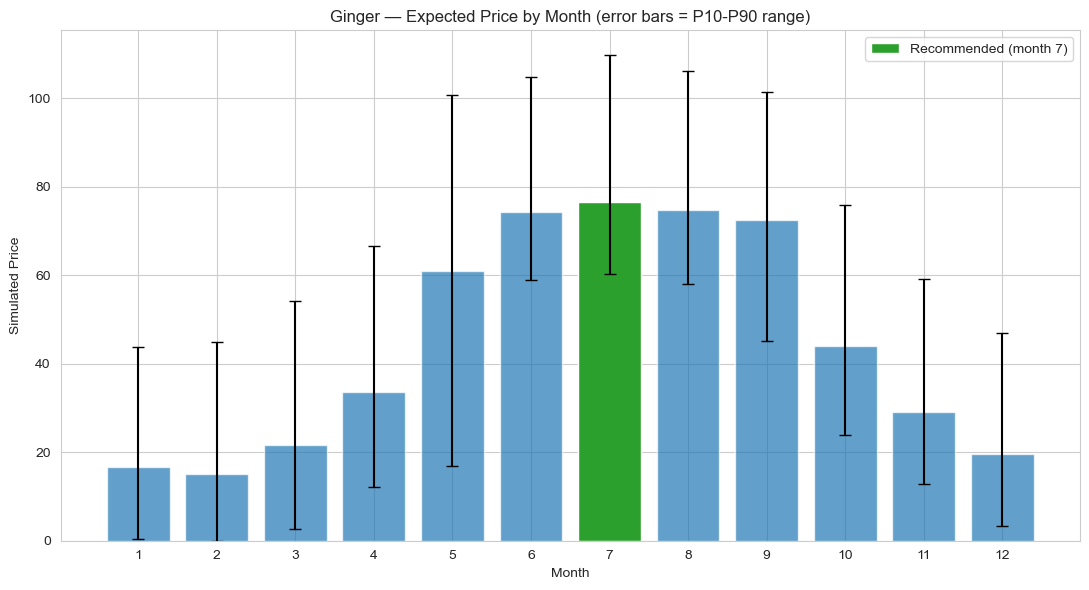

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
order = selling_window.sort_values("month")
ax.bar(order["month"], order["expected_price"],
       yerr=[order["expected_price"] - order["p10"], order["p90"] - order["expected_price"]],
       capsize=4, color="tab:blue", alpha=0.7)
best_m = int(best_month["month"])
ax.bar(best_m, order.loc[order["month"] == best_m, "expected_price"].values[0], color="tab:green",
       label=f"Recommended (month {best_m})")
ax.set_xlabel("Month"); ax.set_ylabel("Simulated Price")
ax.set_xticks(range(1, 13))
ax.set_title(f"{DEMO_COMMODITY} — Expected Price by Month (error bars = P10-P90 range)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/selling_window_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

### Running this for every commodity

The single-commodity version above is for inspection. To generate the recommendation for **every** commodity (or every commodity in a chosen cluster), loop the same logic and collect results into one table.

In [8]:
def farmer_recommendations_for_all(df, commodities, risk_aversion=RISK_AVERSION,
                                     horizon_days=HORIZON_DAYS, n_sims=N_SIMS):
    rows = []
    for c in commodities:
        try:
            paths_c, _, _ = simulate_price_paths(df, c, horizon_days=horizon_days, n_sims=n_sims)
            window = farmer_selling_window(paths_c, risk_aversion)
            best = window.iloc[0]
            rows.append({
                "Commodity": c,
                "recommended_month": int(best["month"]),
                "expected_price": round(best["expected_price"], 2),
                "p10": round(best["p10"], 2),
                "p90": round(best["p90"], 2),
                "cv": round(best["cv"], 3),
            })
        except ValueError as e:
            rows.append({"Commodity": c, "recommended_month": None, "expected_price": None,
                          "p10": None, "p90": None, "cv": None})
    return pd.DataFrame(rows).set_index("Commodity")

# Example: run for the top 10 highest-volume commodities.
# For the full dataset, swap in `df[COMMODITY_COL].unique()` -- note this will take longer
# since it re-fits STL + runs N_SIMS simulations per commodity.
sample_commodities = df[COMMODITY_COL].value_counts().head(10).index.tolist()
farmer_table = farmer_recommendations_for_all(df, sample_commodities)
farmer_table.to_csv(f"{OUTPUT_DIR}/farmer_selling_windows.csv")
print(f"Saved -> {OUTPUT_DIR}/farmer_selling_windows.csv")
farmer_table

Saved -> d:\ShaunakKathavate Github\vegetable_and_fruits_time_series_and_clustering\reports\from notebooks\simulation_outputs/farmer_selling_windows.csv


,recommended_month,expected_price,p10,p90,cv
Commodity,,,,,
Ginger,7,76.64,60.57,110.30,0.303
Cauli Local,9,100.62,85.33,116.37,0.170
Cabbage(Local),11,46.72,33.98,59.20,0.245
Chilli Dry,12,346.80,325.16,370.18,0.076
Raddish White(Local),10,44.29,35.90,57.86,0.243
Potato Red,10,71.20,61.21,83.77,0.138
Bamboo Shoot,5,84.09,53.67,106.02,0.344
Banana,4,125.20,114.17,136.49,0.095
Onion Dry (Indian),11,100.04,70.83,116.73,0.231


### Reading this table for a business audience

- `recommended_month` — the risk-adjusted best month to sell.
- `expected_price` / `p10`-`p90` — what price to realistically expect and plan around, not just a single number to promise a farmer.
- `cv` — how much to caveat the recommendation. A high-CV commodity's "recommended month" is a reasonable bet but with real uncertainty; a low-CV commodity's recommendation is close to a sure thing.

This table is also the natural place to **cross-reference against the earlier cluster labels** (`commodity_clusters_named.csv`) — commodities in a "High Volatility" cluster will generally show high `cv` here too, which is a useful consistency check that the two analyses agree with each other.

## 4. Retailer Procurement Budget Risk (VaR / CVaR)

**Business question:** *"If I'm buying a fixed monthly basket of commodities, what's the realistic range of what that basket will cost me — and what's my exposure in a bad-case month?"*

This reuses the same simulation engine, but with one important upgrade: **a retailer's basket risk isn't just the sum of each commodity's individual risk.** If several commodities spike together — e.g. a monsoon disruption hits multiple vegetables in the same week — the total basket cost swings far more than treating each commodity as independent would suggest. So this section simulates the basket **two ways**, to make that difference visible:

- **Independent simulation** — each commodity gets its own separately-bootstrapped noise (like Section 3). This *overstates* diversification — it assumes bad weeks for onion and bad weeks for tomato never coincide, which isn't realistic.
- **Correlated simulation** — instead of bootstrapping each commodity's residuals separately, it bootstraps the **same historical calendar blocks across every commodity in the basket at once**. If week X in 2019 was a bad week for several vegetables together, that real co-movement gets reproduced in the simulation. No covariance matrix or distributional assumption needed — it's just resampling actual joint history.

In [9]:
def build_common_residuals(df, commodities, period=365):
    """Fit STL per commodity, return (dict of {commodity: (g, res)}, aligned residual matrix).
    The residual matrix keeps only dates where every commodity in the basket has a valid
    residual, so a bootstrapped block reflects a real shared week/month across the whole basket."""
    fits = {}
    resid_series = {}
    for c in commodities:
        g, res = fit_stl(df, c)
        fits[c] = (g, res)
        resid_series[c] = res.resid
    resid_df = pd.DataFrame(resid_series).dropna()
    return fits, resid_df


def simulate_basket_paths_correlated(df, commodities, horizon_days=HORIZON_DAYS,
                                      n_sims=N_SIMS, block_size=BLOCK_SIZE):
    fits, resid_df = build_common_residuals(df, commodities)
    n_common_days = len(resid_df)
    n_blocks_needed = int(np.ceil(horizon_days / block_size))

    # per-commodity trend/seasonal extrapolation (independent -- baseline level and seasonality
    # genuinely differ per commodity, only the *noise* needs to be shared)
    last_date = max(g.index[-1] for g, _ in fits.values())
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon_days, freq="D")

    trend_future = {c: extrapolate_trend(res.trend, horizon_days) for c, (g, res) in fits.items()}
    seasonal_future = {c: extrapolate_seasonal(res.seasonal, future_dates) for c, (g, res) in fits.items()}

    basket_paths = {c: np.zeros((n_sims, horizon_days)) for c in commodities}
    for s in range(n_sims):
        block_starts = np.random.randint(0, n_common_days - block_size, size=n_blocks_needed)
        resid_blocks = np.concatenate([resid_df.values[st:st + block_size] for st in block_starts], axis=0)
        resid_blocks = resid_blocks[:horizon_days]  # shape (horizon_days, n_commodities), SAME blocks for all
        for i, c in enumerate(commodities):
            path = trend_future[c] + seasonal_future[c] + resid_blocks[:, i]
            basket_paths[c][s] = np.clip(path, 0, None)

    return {c: pd.DataFrame(basket_paths[c], columns=future_dates) for c in commodities}


def simulate_basket_paths_independent(df, commodities, horizon_days=HORIZON_DAYS, n_sims=N_SIMS):
    paths = {}
    for c in commodities:
        p, _, _ = simulate_price_paths(df, c, horizon_days=horizon_days, n_sims=n_sims)
        paths[c] = p
    return paths

In [10]:
# Define your basket: commodity -> quantity purchased per period (e.g. kg per month)
BASKET = {
    df[COMMODITY_COL].value_counts().index[0]: 500,
    df[COMMODITY_COL].value_counts().index[1]: 300,
    df[COMMODITY_COL].value_counts().index[2]: 200,
    df[COMMODITY_COL].value_counts().index[3]: 150,
}
print("Basket:", BASKET)

commodities = list(BASKET.keys())
correlated_paths = simulate_basket_paths_correlated(df, commodities)
independent_paths = simulate_basket_paths_independent(df, commodities)

Basket: {'Ginger': 500, 'Cauli Local': 300, 'Cabbage(Local)': 200, 'Chilli Dry': 150}


In [11]:
def basket_monthly_cost(basket_paths, basket_quantities, target_month):
    """Total simulated basket cost for a given future calendar month, one value per simulation."""
    any_c = next(iter(basket_paths))
    future_dates = basket_paths[any_c].columns
    cols = future_dates[future_dates.month == target_month]

    total = np.zeros(basket_paths[any_c].shape[0])
    for c, qty in basket_quantities.items():
        # average daily price in that month * quantity, per simulation
        total += basket_paths[c][cols].mean(axis=1).values * qty
    return total

# example: next occurrence of month 6 (edit as needed)
TARGET_MONTH = correlated_paths[commodities[0]].columns[30].month  # ~1 month out, as a default example

cost_correlated = basket_monthly_cost(correlated_paths, BASKET, TARGET_MONTH)
cost_independent = basket_monthly_cost(independent_paths, BASKET, TARGET_MONTH)

print(f"Target month: {TARGET_MONTH}")
print(f"Correlated model  -- mean cost: {cost_correlated.mean():.0f}, std: {cost_correlated.std():.0f}")
print(f"Independent model -- mean cost: {cost_independent.mean():.0f}, std: {cost_independent.std():.0f}")
print("\n(If the correlated std is noticeably higher, that gap IS the diversification benefit "
      "the independent model was overstating.)")

Target month: 6
Correlated model  -- mean cost: 115165, std: 7929
Independent model -- mean cost: 114992, std: 7335

(If the correlated std is noticeably higher, that gap IS the diversification benefit the independent model was overstating.)


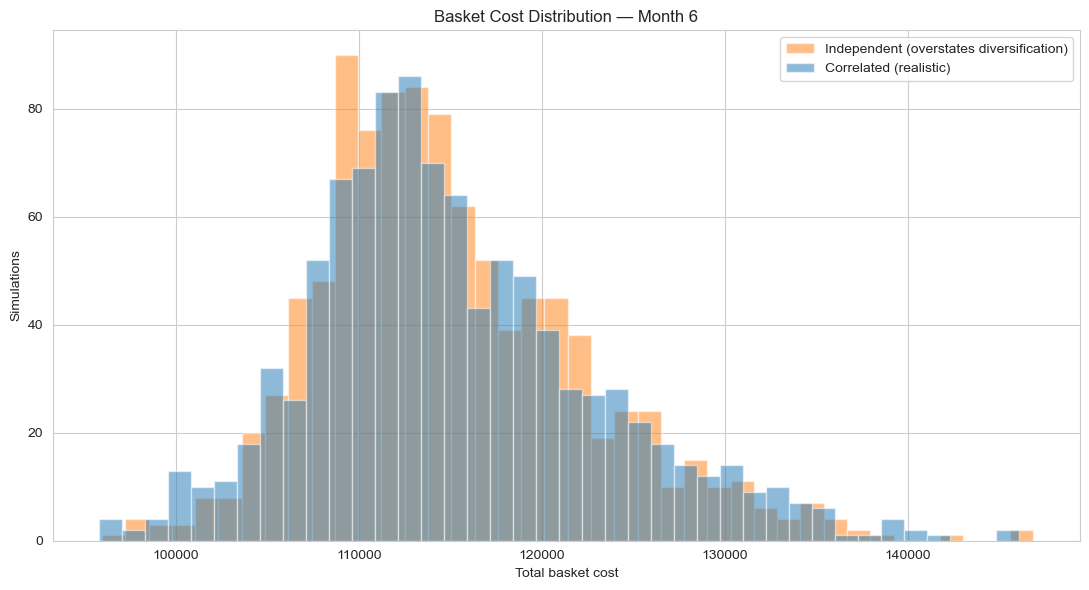

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(cost_independent, bins=40, alpha=0.5, label="Independent (overstates diversification)", color="tab:orange")
ax.hist(cost_correlated, bins=40, alpha=0.5, label="Correlated (realistic)", color="tab:blue")
ax.set_xlabel("Total basket cost"); ax.set_ylabel("Simulations")
ax.set_title(f"Basket Cost Distribution — Month {TARGET_MONTH}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/basket_cost_distribution.png", dpi=150)
plt.show()

### VaR and CVaR

- **VaR (Value at Risk) at 95%** — the cost level you'd only expect to exceed 5% of the time. Read as: *"I'm 95% confident my basket won't cost more than this."*
- **CVaR (Conditional VaR / Expected Shortfall)** — the *average* cost in that worst 5% of outcomes. VaR tells you the threshold; CVaR tells you how bad it typically is once you're past that threshold — more informative for actual budgeting/reserve-setting.

In [13]:
def var_cvar(costs, confidence=0.95):
    var = np.percentile(costs, confidence * 100)
    cvar = costs[costs >= var].mean()
    return var, cvar

CONFIDENCE = 0.95

var_c, cvar_c = var_cvar(cost_correlated, CONFIDENCE)
var_i, cvar_i = var_cvar(cost_independent, CONFIDENCE)

print(f"--- Correlated model (use this one for real budgeting) ---")
print(f"  {int(CONFIDENCE*100)}% VaR:  {var_c:.0f}  (95% chance cost stays under this)")
print(f"  {int(CONFIDENCE*100)}% CVaR: {cvar_c:.0f}  (average cost in the worst 5% of scenarios)")

print(f"\n--- Independent model (shown for comparison only) ---")
print(f"  {int(CONFIDENCE*100)}% VaR:  {var_i:.0f}")
print(f"  {int(CONFIDENCE*100)}% CVaR: {cvar_i:.0f}")

print(f"\nUnderstating risk by using the independent model: "
      f"{cvar_c - cvar_i:.0f} in CVaR terms ({(cvar_c/cvar_i - 1)*100:.1f}% higher real tail risk).")

--- Correlated model (use this one for real budgeting) ---
  95% VaR:  130443  (95% chance cost stays under this)
  95% CVaR: 134538  (average cost in the worst 5% of scenarios)

--- Independent model (shown for comparison only) ---
  95% VaR:  128940
  95% CVaR: 133197

Understating risk by using the independent model: 1340 in CVaR terms (1.0% higher real tail risk).


In [14]:
# Probability of exceeding a specific budget -- the most directly actionable number for planning
BUDGET = cost_correlated.mean() * 1.1   # example: budget set 10% above expected cost -- replace with your real number

prob_exceed_correlated = (cost_correlated > BUDGET).mean()
prob_exceed_independent = (cost_independent > BUDGET).mean()

print(f"Budget: {BUDGET:.0f}")
print(f"Probability of exceeding budget (correlated, realistic):  {prob_exceed_correlated:.1%}")
print(f"Probability of exceeding budget (independent, optimistic): {prob_exceed_independent:.1%}")

Budget: 126681
Probability of exceeding budget (correlated, realistic):  9.1%
Probability of exceeding budget (independent, optimistic): 7.2%


### Reading this for a business audience

- Set `BASKET` to your actual monthly procurement quantities and `BUDGET` to your real budget figure.
- Report the **correlated model's** VaR/CVaR, not the independent one — the independent version is included only to show how much risk gets hidden if commodity co-movement is ignored, which is a common mistake in naive "sum of independent forecasts" budgeting.
- `TARGET_MONTH` currently defaults to ~1 month ahead as an example — set it to whichever future month you're planning for (e.g. the start of the next procurement cycle).
- This same basket framework directly sets up **Section 5 (portfolio diversification)** next: instead of asking "what does this basket cost," that section asks "how would reshuffling the basket mix across volatility/seasonality clusters change this risk."

## 5. Portfolio Diversification Across Clusters

**Business question:** *"If I source from a mix of commodity clusters instead of concentrating in one, how much does that actually reduce my cost risk?"*

This is portfolio theory applied directly to a produce basket: commodities within the same volatility/shape cluster tend to move together (same weather sensitivity, same growing season), so a basket concentrated in one cluster has nowhere to hide when that cluster has a bad month. A basket spread across clusters with *different* seasonal timing and *different* risk drivers smooths out — some items zig while others zag.

This reuses the correlated-basket engine from Section 4, but instead of one fixed basket, it builds several basket variants — from "all one cluster" to "spread across many clusters" — holding the number of commodities and quantity-per-item constant, and compares the resulting cost variance.

In [15]:
# ---- Load cluster assignments from the clustering notebook's output ----
CLUSTER_CSV_PATH = os.path.join(PROJECT_ROOT, "reports", "from notebooks", "clustering_outputs",
                                 "commodity_clusters_named.csv")   # <-- from the clustering notebook
CLUSTER_COL = "volatility_cluster_name"   # swap to "shape_cluster_name" to diversify by seasonal timing instead

clusters_df = pd.read_csv(CLUSTER_CSV_PATH, index_col=0)
cluster_labels = clusters_df[CLUSTER_COL].dropna()

# only keep commodities that actually exist in the raw price data (safety check)
cluster_labels = cluster_labels[cluster_labels.index.isin(df[COMMODITY_COL].unique())]

print(f"{len(cluster_labels)} commodities with a '{CLUSTER_COL}' label")
print(cluster_labels.value_counts())

132 commodities with a 'volatility_cluster_name' label
volatility_cluster_name
High Volatility (Cluster 0)            92
Stable / Low Volatility (Cluster 1)    40
Name: count, dtype: int64


In [16]:
# ---- Filter out commodities with too little history for a yearly STL fit ----
# fit_stl requires >= period * 1.5 days; without this, build_basket can pick a
# short-history commodity (e.g. Litchi(Local)) and crash the sweep below with a ValueError.
MIN_DAYS = int(365 * 1.5)
history_days = df[df[COMMODITY_COL].isin(cluster_labels.index)].groupby(COMMODITY_COL)[DATE_COL].nunique()
valid_commodities = history_days[history_days >= MIN_DAYS].index

n_before = len(cluster_labels)
cluster_labels = cluster_labels[cluster_labels.index.isin(valid_commodities)]
print(f"{len(cluster_labels)}/{n_before} commodities remain after filtering for {MIN_DAYS}+ days of history")
print(cluster_labels.value_counts())

95/132 commodities remain after filtering for 547+ days of history
volatility_cluster_name
High Volatility (Cluster 0)            70
Stable / Low Volatility (Cluster 1)    25
Name: count, dtype: int64


In [17]:
# ---- STL caching: the diversification sweep below refits many overlapping baskets,
# so cache each commodity's STL fit once instead of recomputing it every time it reappears ----
STL_CACHE = {}

def get_stl_cached(df, commodity):
    if commodity not in STL_CACHE:
        STL_CACHE[commodity] = fit_stl(df, commodity)
    return STL_CACHE[commodity]


def build_common_residuals_cached(df, commodities):
    fits = {c: get_stl_cached(df, c) for c in commodities}
    resid_df = pd.DataFrame({c: res.resid for c, (g, res) in fits.items()}).dropna()
    return fits, resid_df


def simulate_basket_paths_correlated_cached(df, commodities, horizon_days=90, n_sims=500, block_size=BLOCK_SIZE):
    fits, resid_df = build_common_residuals_cached(df, commodities)
    n_common_days = len(resid_df)
    n_blocks_needed = int(np.ceil(horizon_days / block_size))
    last_date = max(g.index[-1] for g, _ in fits.values())
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon_days, freq="D")

    trend_future = {c: extrapolate_trend(res.trend, horizon_days) for c, (g, res) in fits.items()}
    seasonal_future = {c: extrapolate_seasonal(res.seasonal, future_dates) for c, (g, res) in fits.items()}

    basket_paths = {c: np.zeros((n_sims, horizon_days)) for c in commodities}
    for s in range(n_sims):
        block_starts = np.random.randint(0, n_common_days - block_size, size=n_blocks_needed)
        resid_blocks = np.concatenate([resid_df.values[st:st + block_size] for st in block_starts], axis=0)[:horizon_days]
        for i, c in enumerate(commodities):
            path = trend_future[c] + seasonal_future[c] + resid_blocks[:, i]
            basket_paths[c][s] = np.clip(path, 0, None)

    return {c: pd.DataFrame(basket_paths[c], columns=future_dates) for c in commodities}

In [18]:
def build_basket(cluster_labels, n_items, n_clusters_to_use, quantity_each=100, random_state=42):
    """Round-robins through `n_clusters_to_use` distinct clusters, picking one new commodity
    from each in turn, until `n_items` total commodities are chosen. n_clusters_to_use=1 gives
    a fully concentrated basket; higher values spread the same number of items across more clusters."""
    rng = np.random.RandomState(random_state)
    available_clusters = cluster_labels.unique().tolist()
    rng.shuffle(available_clusters)
    chosen_clusters = available_clusters[:n_clusters_to_use]

    pools = {c: rng.permutation(cluster_labels[cluster_labels == c].index.values).tolist()
             for c in chosen_clusters}

    basket = {}
    i = 0
    while len(basket) < n_items:
        cluster = chosen_clusters[i % len(chosen_clusters)]
        if pools[cluster]:
            commodity = pools[cluster].pop()
            if commodity not in basket:
                basket[commodity] = quantity_each
        i += 1
        if i > 10_000:  # safety valve if clusters run out of members
            break
    return basket


N_ITEMS = 6          # basket size to compare across all diversification levels
QTY_EACH = 100
SWEEP_HORIZON = 90   # shorter horizon here since this cell runs many simulations
SWEEP_N_SIMS = 400   # lower sim count for the sweep to keep runtime reasonable; bump up for a final report

max_clusters = cluster_labels.nunique()
print(f"Sweeping from 1 to {max_clusters} distinct clusters, {N_ITEMS} commodities per basket")

Sweeping from 1 to 2 distinct clusters, 6 commodities per basket


In [19]:
sweep_results = []
for n_clusters in range(1, max_clusters + 1):
    basket = build_basket(cluster_labels, N_ITEMS, n_clusters, QTY_EACH)
    if len(basket) < N_ITEMS:
        continue  # not enough distinct commodities available at this diversification level -- skip
    paths = simulate_basket_paths_correlated_cached(df, list(basket.keys()),
                                                      horizon_days=SWEEP_HORIZON, n_sims=SWEEP_N_SIMS)
    total_cost = np.zeros(SWEEP_N_SIMS)
    for c, qty in basket.items():
        total_cost += paths[c].mean(axis=1).values * qty

    sweep_results.append({
        "n_clusters_used": n_clusters,
        "mean_cost": total_cost.mean(),
        "std_cost": total_cost.std(),
        "cv": total_cost.std() / total_cost.mean(),
        "basket": list(basket.keys()),
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df[["n_clusters_used", "mean_cost", "std_cost", "cv"]]

,n_clusters_used,mean_cost,std_cost,cv
0,1,42781.311720,895.875072,0.020941
1,2,77870.569282,616.134572,0.007912


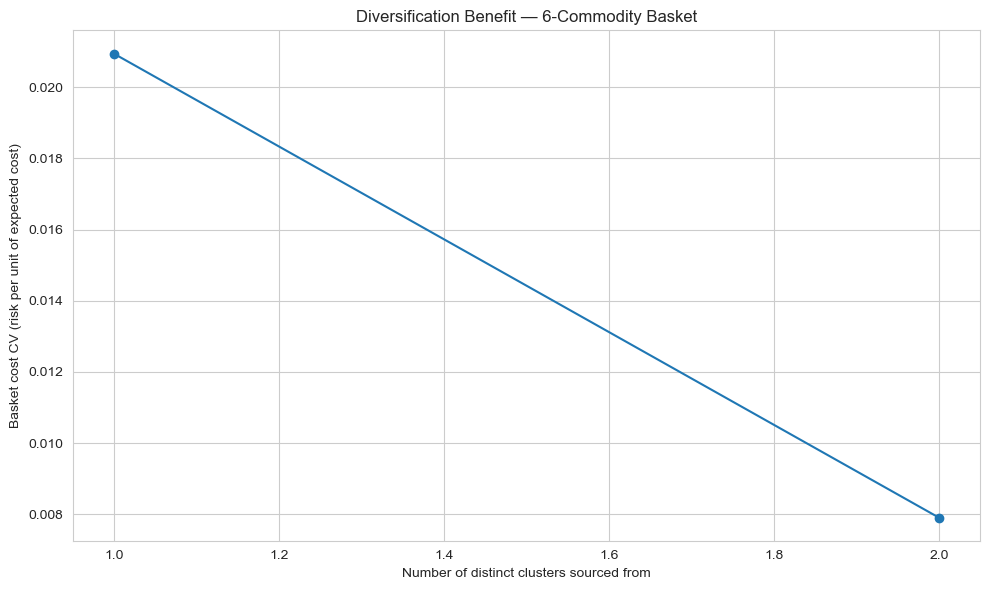

Risk (CV) at 1 cluster: 0.021
Risk (CV) at 2 clusters: 0.008
Relative risk reduction from full diversification: 62.2%


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep_df["n_clusters_used"], sweep_df["cv"], marker="o", color="tab:blue")
ax.set_xlabel("Number of distinct clusters sourced from")
ax.set_ylabel("Basket cost CV (risk per unit of expected cost)")
ax.set_title(f"Diversification Benefit — {N_ITEMS}-Commodity Basket")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diversification_curve.png", dpi=150)
plt.show()

reduction = (sweep_df['cv'].iloc[0] - sweep_df['cv'].iloc[-1]) / sweep_df['cv'].iloc[0]
print(f"Risk (CV) at 1 cluster: {sweep_df['cv'].iloc[0]:.3f}")
print(f"Risk (CV) at {sweep_df['n_clusters_used'].iloc[-1]} clusters: {sweep_df['cv'].iloc[-1]:.3f}")
print(f"Relative risk reduction from full diversification: {reduction:.1%}")

In [21]:
# Direct side-by-side: most concentrated vs most diversified basket, same N_ITEMS and quantities
concentrated_row = sweep_df.iloc[0]
diversified_row = sweep_df.iloc[-1]

print("Concentrated basket (1 cluster):")
print(" ", concentrated_row["basket"])
print(f"  mean cost: {concentrated_row['mean_cost']:.0f}, CV: {concentrated_row['cv']:.3f}")

print("\nDiversified basket (max clusters):")
print(" ", diversified_row["basket"])
print(f"  mean cost: {diversified_row['mean_cost']:.0f}, CV: {diversified_row['cv']:.3f}")

print(f"\nSame expected spend, {reduction:.1%} less relative cost volatility just from sourcing mix — "
      f"no change in total quantity purchased.")

Concentrated basket (1 cluster):
  ['Raddish White(Local)', 'Cauli Terai', 'Sugarbeet', 'Cress Leaf', 'Fennel Leaf', 'Banana']
  mean cost: 42781, CV: 0.021

Diversified basket (max clusters):
  ['Raddish White(Local)', 'Lime', 'Cauli Terai', 'Gundruk', 'Sugarbeet', 'Fish Fresh(Bachuwa)']
  mean cost: 77871, CV: 0.008

Same expected spend, 62.2% less relative cost volatility just from sourcing mix — no change in total quantity purchased.


### Reading this for a business audience

- The curve should slope downward: as the basket spans more distinct clusters, cost volatility (CV) typically drops, then flattens — the classic diminishing-returns diversification curve from portfolio theory. If it's flat or noisy, it usually means `N_ITEMS` is too small relative to `max_clusters`, or the chosen `CLUSTER_COL` (volatility vs. shape) isn't the risk driver that matters most for this basket — try switching between `volatility_cluster_name` and `shape_cluster_name`.
- **Mean cost stays roughly the same** across diversification levels — this is risk reduction with no cost trade-off, which is the strongest possible pitch to a retailer: same expected spend, meaningfully less exposure to a bad month.
- Swap `CLUSTER_COL` to `shape_cluster_name` to diversify by *seasonal timing* specifically (commodities that peak in different months) rather than by raw volatility — often the more actionable axis for a retailer planning month-to-month sourcing.
- `SWEEP_N_SIMS` is deliberately lower than the main `N_SIMS` since this cell runs the full simulation once per diversification level — raise it for a final report once you're happy with the basket construction logic.

## 6. Consumer "Good Time to Buy" Indicator

**Business question:** *"Is today's price for this commodity actually a good deal, or just normal for this time of year?"*

This compares today's actual price against the **simulated seasonal-normal distribution** for that same calendar month — the same Monte Carlo engine from Section 1, just read differently: instead of asking "what's the best month," it asks "where does today's real price fall within the range of prices that are typical for right now."

In [22]:
def consumer_buy_timing(df, commodity, current_price=None, current_date=None,
                          horizon_days=90, n_sims=N_SIMS):
    g, res = get_stl_cached(df, commodity) if commodity in STL_CACHE else fit_stl(df, commodity)

    # default to the most recent actual observation as "today", if not supplied
    if current_price is None or current_date is None:
        current_price = g.iloc[-1]
        current_date = g.index[-1]

    target_month = pd.Timestamp(current_date).month

    paths, _, _ = simulate_price_paths(df, commodity, horizon_days=horizon_days, n_sims=n_sims)
    future_dates = paths.columns
    cols = future_dates[future_dates.month == target_month]
    if len(cols) == 0:
        # target month not reached within the horizon -- extend it until it is
        paths, _, _ = simulate_price_paths(df, commodity, horizon_days=400, n_sims=n_sims)
        future_dates = paths.columns
        cols = future_dates[future_dates.month == target_month]

    typical_dist = paths[cols].values.flatten()

    cheaper_than_pct = (typical_dist > current_price).mean() * 100   # price beats this % of typical prices
    more_expensive_than_pct = 100 - cheaper_than_pct

    if cheaper_than_pct >= 70:
        verdict = "Good time to buy"
    elif cheaper_than_pct <= 30:
        verdict = "Expensive right now"
    else:
        verdict = "Roughly average pricing"

    month_name = pd.Timestamp(current_date).strftime("%B")

    return {
        "commodity": commodity,
        "current_price": round(float(current_price), 2),
        "current_date": pd.Timestamp(current_date).date(),
        "month": month_name,
        "typical_median": round(float(np.median(typical_dist)), 2),
        "typical_p10": round(float(np.percentile(typical_dist, 10)), 2),
        "typical_p90": round(float(np.percentile(typical_dist, 90)), 2),
        "cheaper_than_pct": round(cheaper_than_pct, 1),
        "verdict": verdict,
        "message": (f"Today's {commodity} price ({current_price:.2f}) is cheaper than "
                    f"{cheaper_than_pct:.0f}% of typical {month_name} prices — {verdict.lower()}."),
    }

In [23]:
DEMO_CONSUMER_COMMODITY = df[COMMODITY_COL].value_counts().index[0]
result = consumer_buy_timing(df, DEMO_CONSUMER_COMMODITY)

for k, v in result.items():
    if k != "message":
        print(f"{k}: {v}")
print("\n" + result["message"])

commodity: Ginger
current_price: 85.0
current_date: 2021-05-13
month: May
typical_median: 76.46
typical_p10: 63.1
typical_p90: 120.29
cheaper_than_pct: 38.1
verdict: Roughly average pricing

Today's Ginger price (85.00) is cheaper than 38% of typical May prices — roughly average pricing.


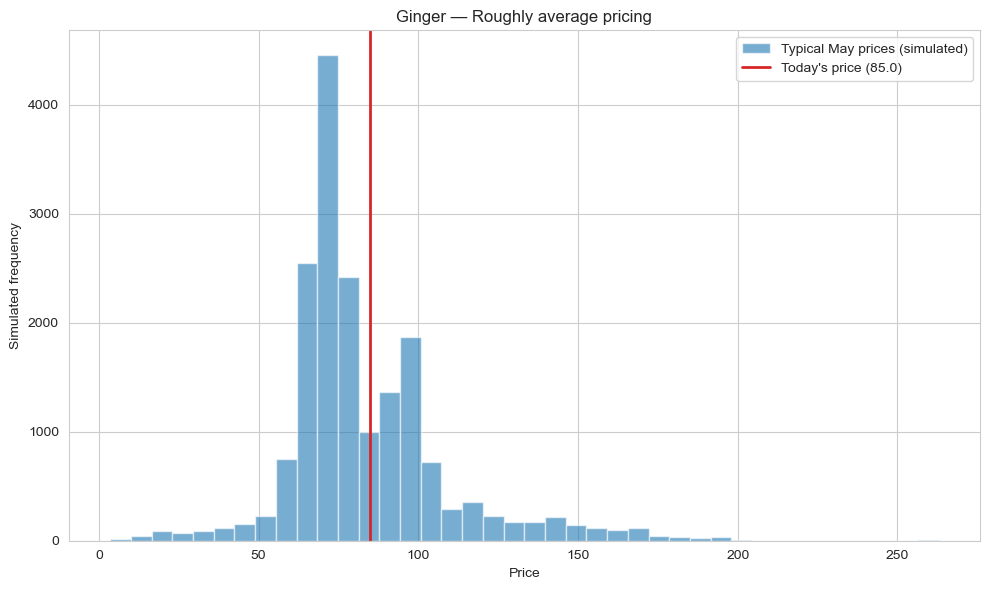

In [24]:
# visualize where today's price sits within the typical distribution
paths_demo, _, _ = simulate_price_paths(df, DEMO_CONSUMER_COMMODITY, horizon_days=90, n_sims=N_SIMS)
target_month = pd.Timestamp(result["current_date"]).month
cols = paths_demo.columns[paths_demo.columns.month == target_month]
typical_dist = paths_demo[cols].values.flatten()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(typical_dist, bins=40, color="tab:blue", alpha=0.6, label=f"Typical {result['month']} prices (simulated)")
ax.axvline(result["current_price"], color="tab:red", linewidth=2, label=f"Today's price ({result['current_price']})")
ax.set_xlabel("Price"); ax.set_ylabel("Simulated frequency")
ax.set_title(f"{DEMO_CONSUMER_COMMODITY} — {result['verdict']}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/buy_timing_{DEMO_CONSUMER_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

In [25]:
# Batch version -- a "today's shopping list" indicator across several commodities at once
def buy_timing_for_all(df, commodities, n_sims=N_SIMS):
    rows = []
    for c in commodities:
        try:
            r = consumer_buy_timing(df, c, n_sims=n_sims)
            rows.append(r)
        except ValueError:
            continue
    return pd.DataFrame(rows).set_index("commodity")

sample_commodities = df[COMMODITY_COL].value_counts().head(8).index.tolist()
shopping_list = buy_timing_for_all(df, sample_commodities)
shopping_list.to_csv(f"{OUTPUT_DIR}/consumer_buy_timing.csv")
print(f"Saved -> {OUTPUT_DIR}/consumer_buy_timing.csv")
shopping_list[["current_price", "typical_median", "cheaper_than_pct", "verdict"]]

Saved -> d:\ShaunakKathavate Github\vegetable_and_fruits_time_series_and_clustering\reports\from notebooks\simulation_outputs/consumer_buy_timing.csv


,current_price,typical_median,cheaper_than_pct,verdict
commodity,,,,
Ginger,85.0,76.07,36.6,Roughly average pricing
Cauli Local,37.5,56.32,93.8,Good time to buy
Cabbage(Local),22.5,20.71,39.0,Roughly average pricing
Chilli Dry,325.0,332.55,65.9,Roughly average pricing
Raddish White(Local),17.5,29.10,96.4,Good time to buy
Potato Red,36.0,44.85,94.1,Good time to buy
Bamboo Shoot,95.0,97.43,60.8,Roughly average pricing
Banana,105.0,114.25,90.3,Good time to buy


### Reading this for a business audience / a consumer-facing app

- `cheaper_than_pct` is the headline number — "cheaper than 80% of typical prices" is intuitive without needing to explain percentiles, CVs, or simulations.
- The verdict thresholds (`>=70` good time to buy, `<=30` expensive) are simple defaults — tune them based on how sensitive you want the indicator to be.
- This is naturally exposed as a live indicator: rerun with today's actual scraped/reported price as `current_price` and today's date as `current_date`, rather than relying on the dataset's last row.
- Because it reuses the same STL + bootstrap engine as every other section, the "typical" distribution automatically accounts for both the commodity's seasonal pattern *and* its overall price trend — so it won't flag something as "cheap" just because it's below a stale multi-year average that inflation/trend has since moved past.

## 7. Summary

All four business simulations now share the same underlying Monte Carlo engine (Section 1), so results are consistent with each other:

| Section | Output file | Answers |
|---|---|---|
| 3. Farmer selling window | `farmer_selling_windows.csv` | Best month to sell, risk-adjusted |
| 4. Retailer budget risk | (VaR/CVaR printed; edit `BASKET`/`BUDGET` for your numbers) | Probability of exceeding a procurement budget |
| 5. Portfolio diversification | `diversification_curve.png` | How much sourcing-mix diversification reduces cost risk |
| 6. Consumer buy-timing | `consumer_buy_timing.csv` | Is today's price actually a good deal |

All of these are transparent about their own assumptions (recent-trend extrapolation, historically-repeating seasonality, bootstrap-resampled noise) rather than presenting a single confident number — which is the right posture for a business audience: show the range, show the confidence, let the decision-maker weigh the trade-off.